In [1]:
!pip install wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Paleta del proyecto
C1 = '#E63946'   # rojo — negativo
C2 = '#457B9D'   # azul — neutro / general
C3 = '#2D6A4F'   # verde — positivo
C4 = '#F4A261'   # naranja — acento

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

# Subir dataset con sentimiento
from google.colab import files
uploaded = files.upload()
import io
nombre = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre]))

print(f"✓ Dataset cargado: {df.shape}")
print(f"  Destinos: {df['destino'].nunique()}")
print(f"  Reseñas:  {len(df)}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving tripadvisor_ecuador_sentimiento.csv to tripadvisor_ecuador_sentimiento (3).csv
✓ Dataset cargado: (43, 19)
  Destinos: 8
  Reseñas:  43


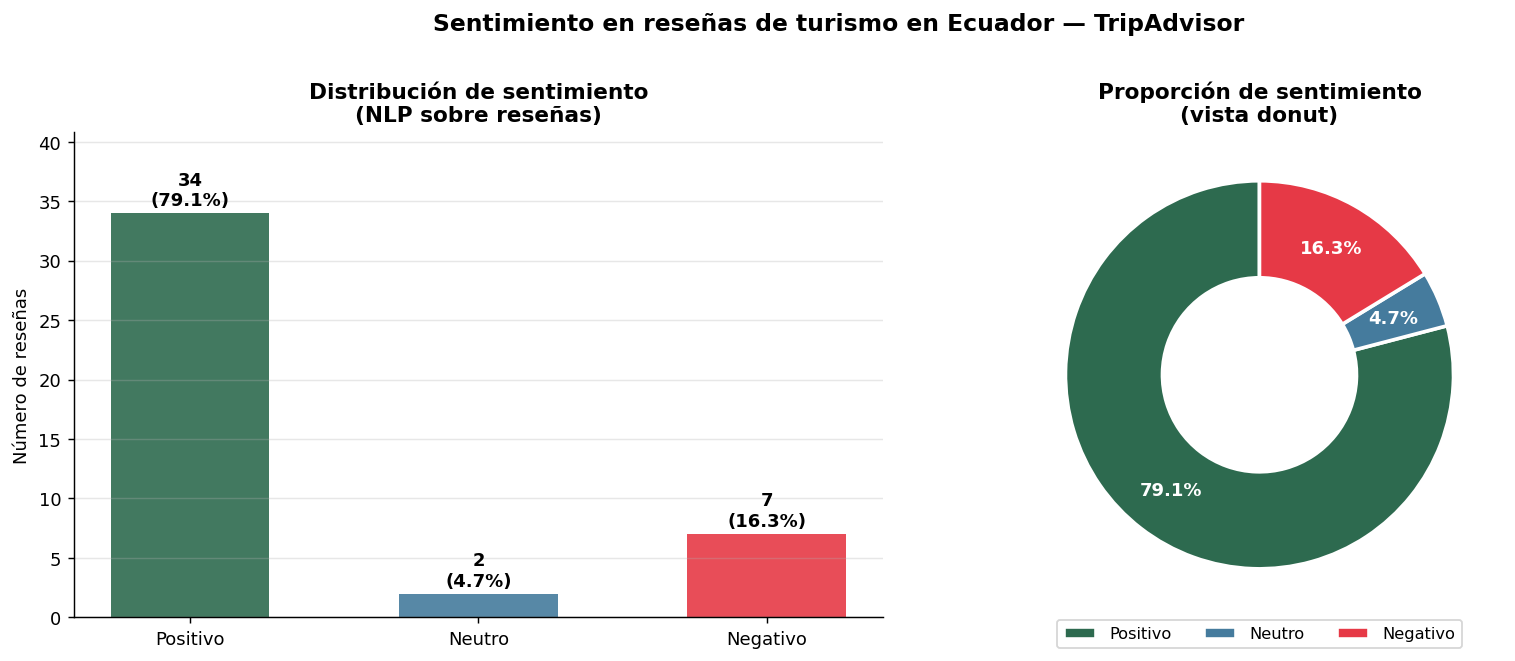

✓ Figura 1 guardada


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: barras por sentimiento ────────────────
conteo = df['sentimiento_nlp'].value_counts()
orden  = ['POS', 'NEU', 'NEG']
vals   = [conteo.get(s, 0) for s in orden]
cols   = [C3, C2, C1]
etiq   = ['Positivo', 'Neutro', 'Negativo']

ax = axes[0]
bars = ax.bar(etiq, vals, color=cols, width=0.55, alpha=0.9)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribución de sentimiento\n(NLP sobre reseñas)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Número de reseñas')
ax.set_ylim(0, max(vals) * 1.2)
ax.grid(axis='y', alpha=0.3)

# ── Panel derecho: donut chart ─────────────────────────────
ax2 = axes[1]
sizes = [conteo.get(s, 0) for s in orden]
wedges, texts, autotexts = ax2.pie(
    sizes, colors=cols, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
ax2.legend(etiq, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9)
ax2.set_title('Proporción de sentimiento\n(vista donut)',
              fontsize=12, fontweight='bold')

plt.suptitle(
    'Sentimiento en reseñas de turismo en Ecuador — TripAdvisor',
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_distribucion_sentimiento.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 1 guardada")

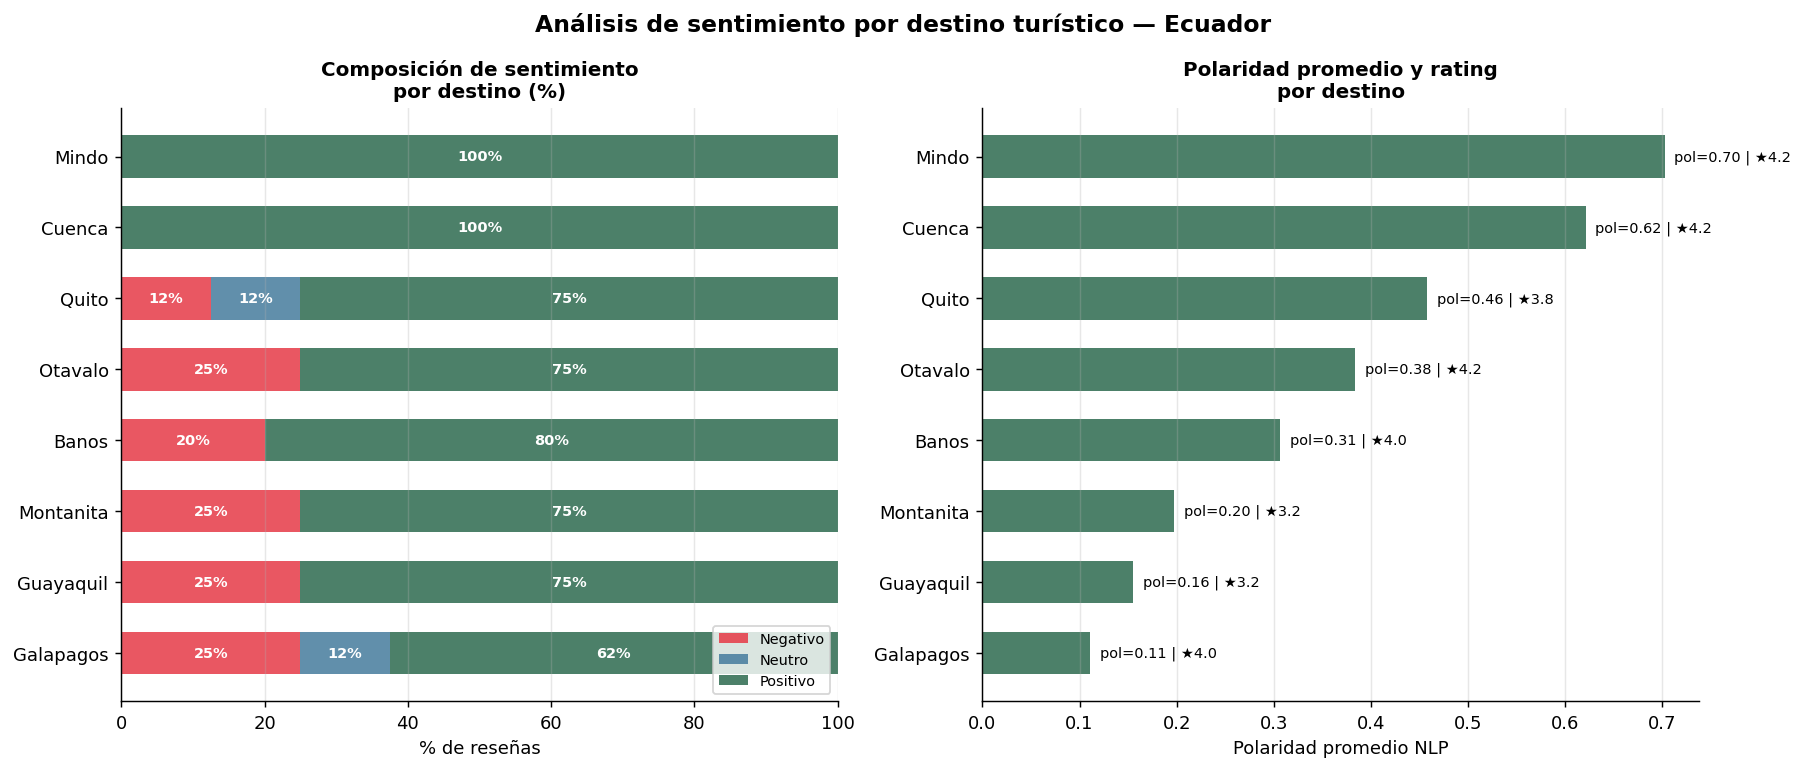

✓ Figura 2 guardada


In [3]:
# Calcular métricas por destino
orden_destinos = (df.groupby('destino')['polaridad_nlp']
                    .mean()
                    .sort_values(ascending=True)
                    .index.tolist())

sent_dest = (df.groupby(['destino', 'sentimiento_nlp'])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=['NEG','NEU','POS'], fill_value=0))

sent_dest = sent_dest.loc[orden_destinos]
sent_dest_pct = sent_dest.div(sent_dest.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel izquierdo: barras apiladas % ────────────────────
ax = axes[0]
bottom = np.zeros(len(sent_dest_pct))
for col, color, label in zip(
        ['NEG','NEU','POS'], [C1,C2,C3],
        ['Negativo','Neutro','Positivo']):
    vals = sent_dest_pct[col].values
    ax.barh(sent_dest_pct.index, vals,
            left=bottom, color=color,
            alpha=0.85, label=label, height=0.6)
    # Etiqueta si el segmento es suficientemente ancho
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax.text(b + v/2, i, f'{v:.0f}%',
                    ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xlabel('% de reseñas')
ax.set_title('Composición de sentimiento\npor destino (%)',
             fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)

# ── Panel derecho: polaridad promedio ─────────────────────
ax2 = axes[1]
pol_media = (df.groupby('destino')['polaridad_nlp']
               .mean()
               .reindex(orden_destinos))
rating_med = (df.groupby('destino')['rating']
                .mean()
                .reindex(orden_destinos))

cols_barra = [C3 if v >= 0 else C1 for v in pol_media.values]
bars = ax2.barh(pol_media.index, pol_media.values,
                color=cols_barra, alpha=0.85, height=0.6)
ax2.axvline(0, color='black', lw=1)

for bar, val, rat in zip(bars, pol_media.values, rating_med.values):
    offset = 0.01 if val >= 0 else -0.01
    ha     = 'left' if val >= 0 else 'right'
    ax2.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'pol={val:.2f} | ★{rat:.1f}',
             va='center', ha=ha, fontsize=8)

ax2.set_xlabel('Polaridad promedio NLP')
ax2.set_title('Polaridad promedio y rating\npor destino',
              fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Análisis de sentimiento por destino turístico — Ecuador',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_sentimiento_por_destino.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 2 guardada")

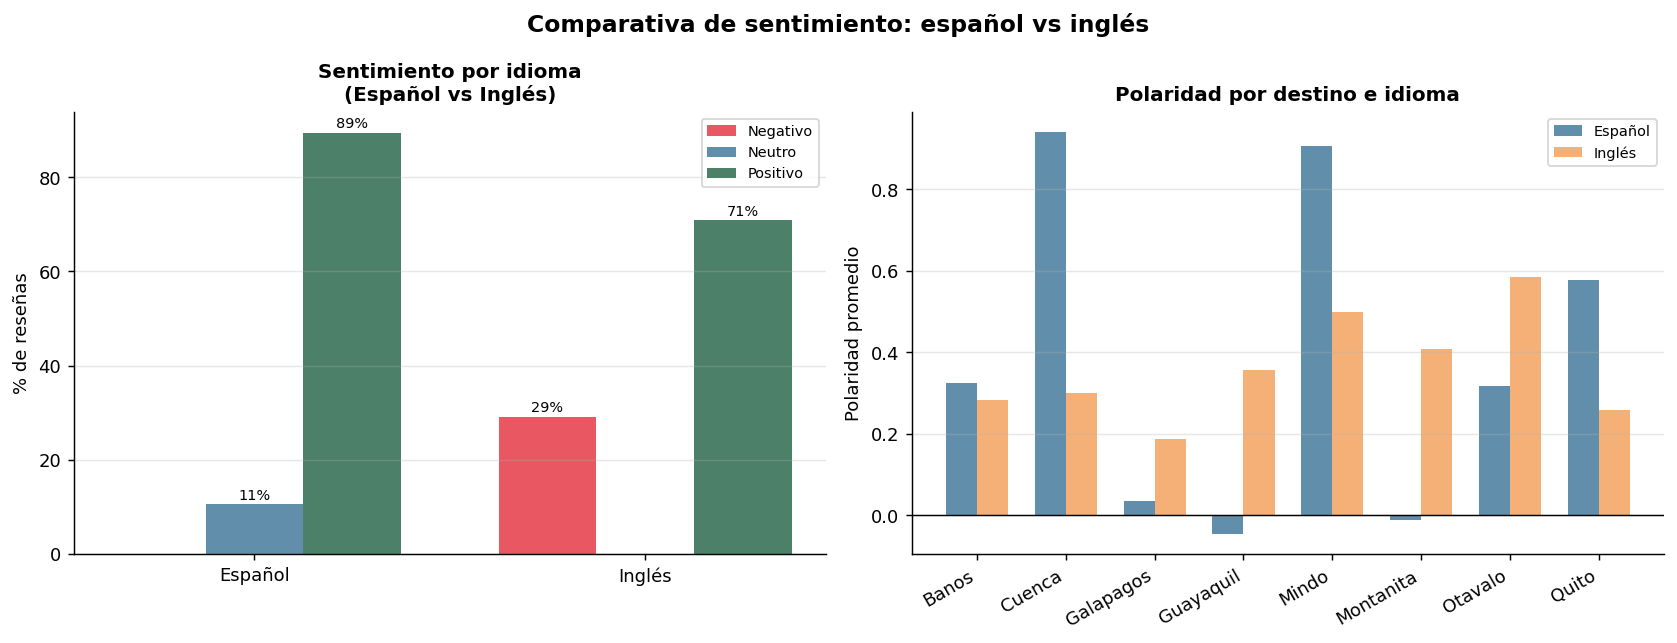

✓ Figura 3 guardada


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: distribución sentimiento por idioma ──
sent_idioma = (df.groupby(['idioma','sentimiento_nlp'])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(columns=['NEG','NEU','POS'], fill_value=0))
sent_idioma_pct = sent_idioma.div(sent_idioma.sum(axis=1), axis=0) * 100
sent_idioma.index = ['Español', 'Inglés']
sent_idioma_pct.index = ['Español', 'Inglés']

ax = axes[0]
x = np.arange(len(sent_idioma_pct))
w = 0.25
for j, (col, color, label) in enumerate(
        zip(['NEG','NEU','POS'], [C1,C2,C3],
            ['Negativo','Neutro','Positivo'])):
    vals = sent_idioma_pct[col].values
    bars = ax.bar(x + j*w, vals, width=w,
                  color=color, alpha=0.85, label=label)
    for bar, val in zip(bars, vals):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f'{val:.0f}%', ha='center',
                    va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels(['Español', 'Inglés'])
ax.set_ylabel('% de reseñas')
ax.set_title('Sentimiento por idioma\n(Español vs Inglés)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel derecho: polaridad e idioma por destino ─────────
ax2 = axes[1]
pivot = df.pivot_table(values='polaridad_nlp',
                       index='destino',
                       columns='idioma',
                       aggfunc='mean')
# Rellenar NaN para destinos sin un idioma
pivot = pivot.fillna(0)
pivot.columns = ['Español' if c=='es' else 'Inglés'
                 for c in pivot.columns]

x2  = np.arange(len(pivot))
w2  = 0.35
ax2.bar(x2 - w2/2, pivot['Español'], width=w2,
        color=C2, alpha=0.85, label='Español')
if 'Inglés' in pivot.columns:
    ax2.bar(x2 + w2/2, pivot['Inglés'], width=w2,
            color=C4, alpha=0.85, label='Inglés')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels(pivot.index, rotation=30, ha='right')
ax2.set_ylabel('Polaridad promedio')
ax2.set_title('Polaridad por destino e idioma',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Comparativa de sentimiento: español vs inglés',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_sentimiento_por_idioma.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 3 guardada")

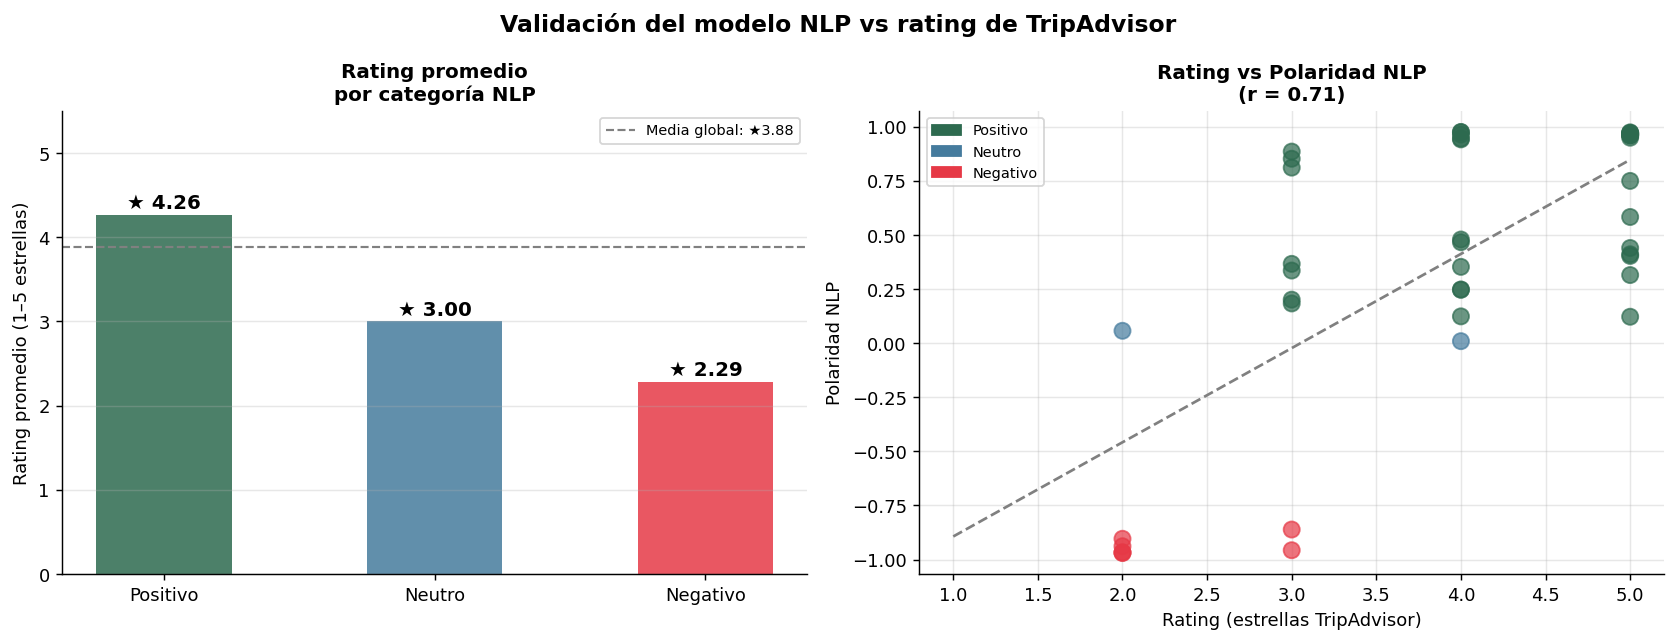

✓ Figura 4 guardada


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel izquierdo: rating promedio por sentimiento NLP ──
ax = axes[0]
rating_sent = (df[df['rating'].notna()]
               .groupby('sentimiento_nlp')['rating']
               .mean()
               .reindex(['POS','NEU','NEG']))
cols_rs = [C3, C2, C1]
bars = ax.bar(['Positivo','Neutro','Negativo'],
              rating_sent.values, color=cols_rs,
              width=0.5, alpha=0.85)
for bar, val in zip(bars, rating_sent.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03,
            f'★ {val:.2f}', ha='center',
            va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.set_ylabel('Rating promedio (1–5 estrellas)')
ax.set_title('Rating promedio\npor categoría NLP',
             fontsize=11, fontweight='bold')
ax.axhline(df['rating'].mean(), color='gray',
           linestyle='--', lw=1.2,
           label=f'Media global: ★{df["rating"].mean():.2f}')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel derecho: scatter polaridad vs rating ────────────
ax2 = axes[1]
cols_punt = df['sentimiento_nlp'].map(
    {'POS': C3, 'NEU': C2, 'NEG': C1})
ax2.scatter(df['rating'], df['polaridad_nlp'],
            c=cols_punt, alpha=0.7, s=80, zorder=3)
# Línea de tendencia
df_val2 = df[df['rating'].notna() & df['polaridad_nlp'].notna()]
z = np.polyfit(df_val2['rating'], df_val2['polaridad_nlp'], 1)
p = np.poly1d(z)
x_line = np.linspace(1, 5, 100)
ax2.plot(x_line, p(x_line), color='gray',
         linestyle='--', lw=1.5, label='Tendencia')

corr = df_val2['rating'].corr(df_val2['polaridad_nlp'])
ax2.set_xlabel('Rating (estrellas TripAdvisor)')
ax2.set_ylabel('Polaridad NLP')
ax2.set_title(f'Rating vs Polaridad NLP\n(r = {corr:.2f})',
              fontsize=11, fontweight='bold')
parches = [
    mpatches.Patch(color=C3, label='Positivo'),
    mpatches.Patch(color=C2, label='Neutro'),
    mpatches.Patch(color=C1, label='Negativo'),
]
ax2.legend(handles=parches, fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle('Validación del modelo NLP vs rating de TripAdvisor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_validacion_nlp_rating.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 4 guardada")

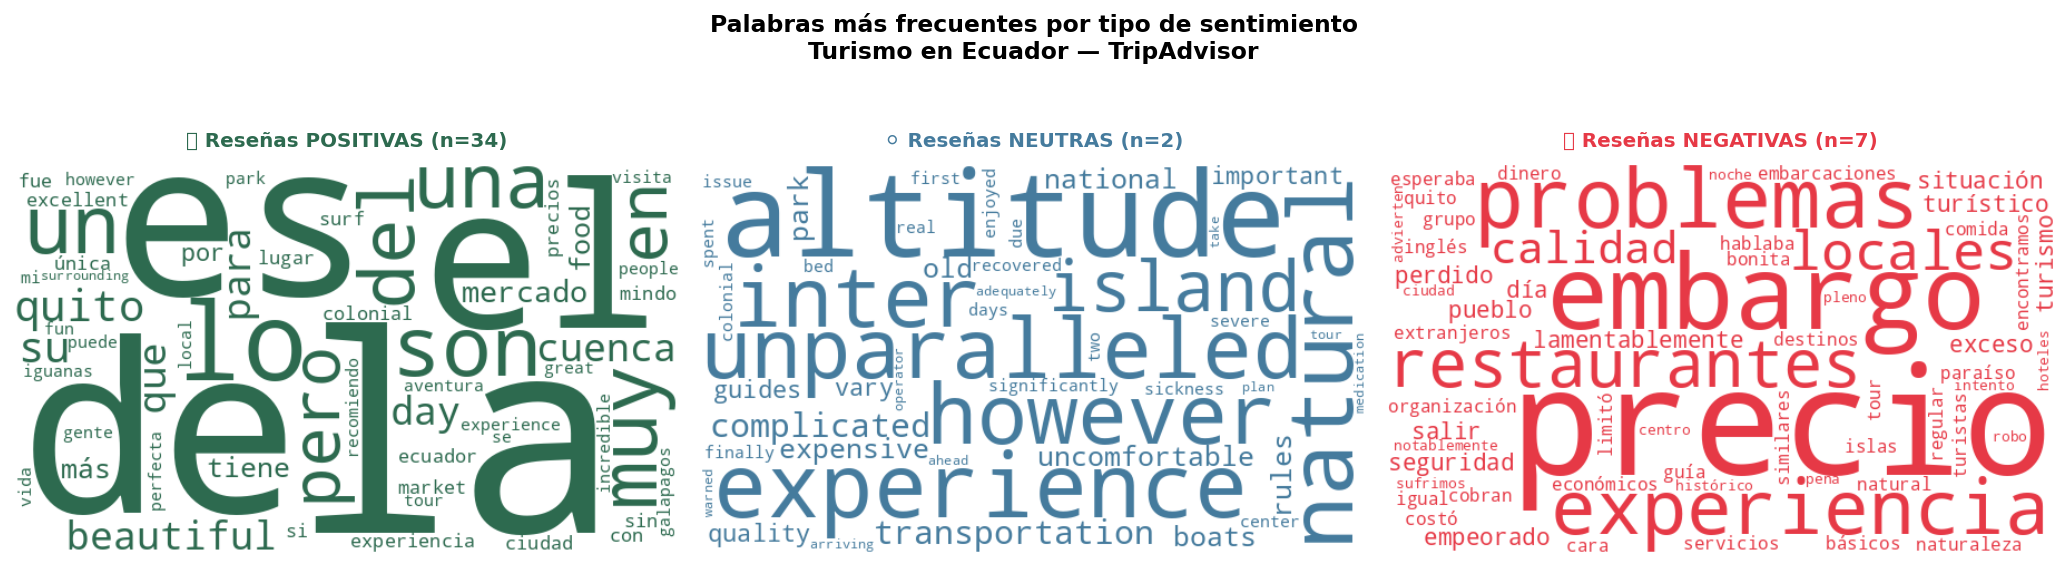

✓ Figura 5 guardada


In [6]:
from wordcloud import WordCloud

STOPWORDS_ES = set(stopwords.words('spanish')) | {
    'más','ser','está','todo','muy','bien','hacer',
    'hay','así','sido','esto','eso','también','aunque',
    'puede','cada','solo','solo','si','vez'}

STOPWORDS_EN = set(stopwords.words('english')) | {
    'really','would','also','much','many','every',
    'even','still','quite','got','one','us','get'}

def generar_wordcloud(textos, idioma, titulo, color, ax):
    stopwords_uso = STOPWORDS_ES if idioma == 'es' else STOPWORDS_EN
    texto_unido = ' '.join(textos).lower()
    texto_unido = re.sub(r'[^a-záéíóúüña-z\s]', ' ', texto_unido)

    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=None,
        color_func=lambda *args, **kwargs: color,
        stopwords=stopwords_uso,
        max_words=60,
        prefer_horizontal=0.8,
        min_font_size=8,
    ).generate(texto_unido)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(titulo, fontsize=11, fontweight='bold',
                 color=color, pad=10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

textos_pos = df[df['sentimiento_nlp']=='POS']['texto_limpio'].dropna().tolist()
textos_neu = df[df['sentimiento_nlp']=='NEU']['texto_limpio'].dropna().tolist()
textos_neg = df[df['sentimiento_nlp']=='NEG']['texto_limpio'].dropna().tolist()

# Idioma predominante por grupo
idioma_pos = 'es' if df[df['sentimiento_nlp']=='POS']['idioma'].value_counts().idxmax()=='es' else 'en'
idioma_neu = 'es' if df[df['sentimiento_nlp']=='NEU']['idioma'].value_counts().idxmax()=='es' else 'en'
idioma_neg = 'es' if df[df['sentimiento_nlp']=='NEG']['idioma'].value_counts().idxmax()=='es' else 'en'

generar_wordcloud(textos_pos, idioma_pos,
                  f'✅ Reseñas POSITIVAS (n={len(textos_pos)})',
                  '#2D6A4F', axes[0])
generar_wordcloud(textos_neu, idioma_neu,
                  f'⚪ Reseñas NEUTRAS (n={len(textos_neu)})',
                  '#457B9D', axes[1])
generar_wordcloud(textos_neg, idioma_neg,
                  f'❌ Reseñas NEGATIVAS (n={len(textos_neg)})',
                  '#E63946', axes[2])

plt.suptitle('Palabras más frecuentes por tipo de sentimiento\n'
             'Turismo en Ecuador — TripAdvisor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_wordcloud_sentimiento.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 5 guardada")

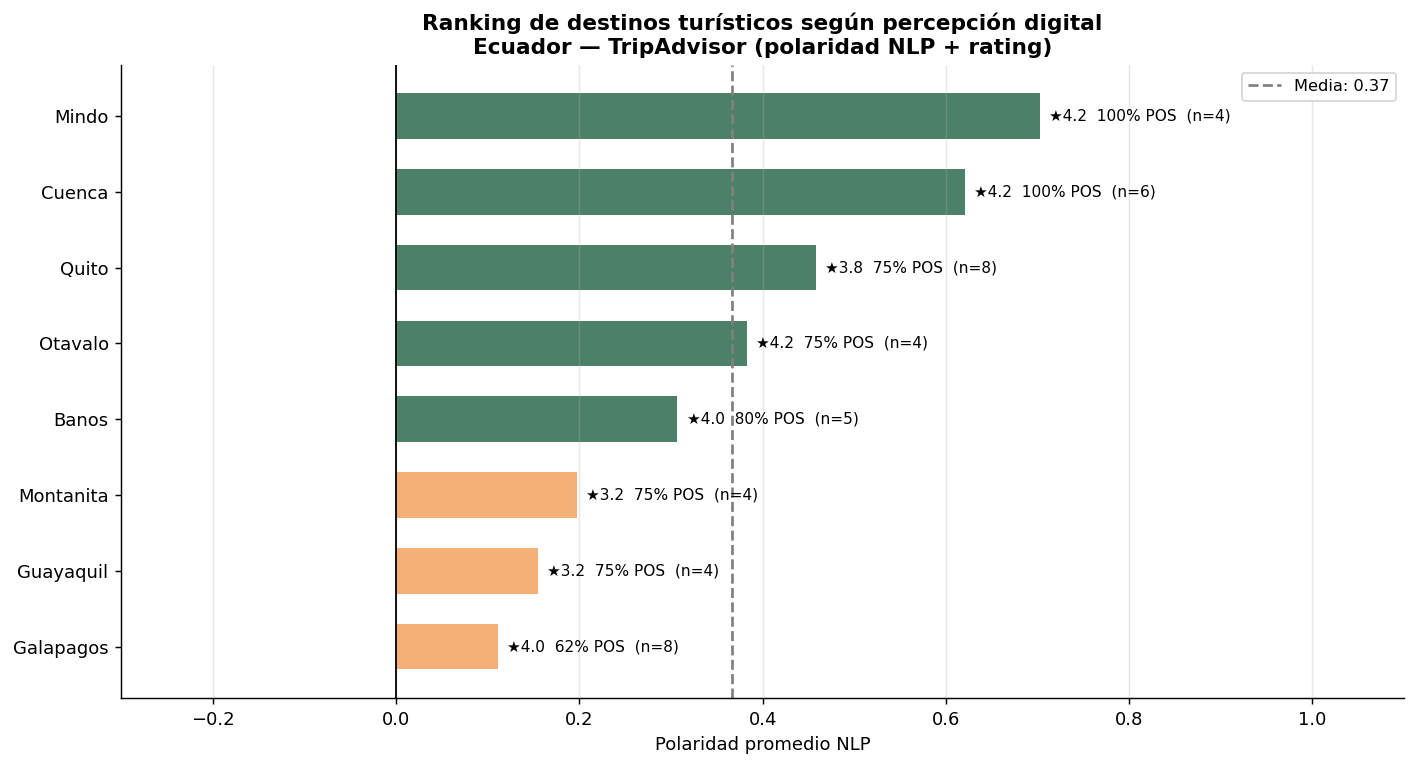

✓ Figura 6 guardada


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

resumen = df.groupby('destino').agg(
    polaridad   = ('polaridad_nlp', 'mean'),
    rating      = ('rating', 'mean'),
    n_resenas   = ('sentimiento_nlp', 'count'),
    pct_pos     = ('sentimiento_nlp', lambda x: (x=='POS').mean()*100),
).sort_values('polaridad', ascending=True).round(3)

colores = [C3 if v >= 0.2 else C4 if v >= 0 else C1
           for v in resumen['polaridad']]

bars = ax.barh(resumen.index, resumen['polaridad'],
               color=colores, alpha=0.85, height=0.6)
ax.axvline(0, color='black', lw=1)
ax.axvline(resumen['polaridad'].mean(), color='gray',
           lw=1.5, linestyle='--',
           label=f'Media: {resumen["polaridad"].mean():.2f}')

for bar, (dest, row) in zip(bars, resumen.iterrows()):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'★{row["rating"]:.1f}  {row["pct_pos"]:.0f}% POS  '
            f'(n={int(row["n_resenas"])})',
            va='center', fontsize=8.5)

ax.set_xlabel('Polaridad promedio NLP')
ax.set_title('Ranking de destinos turísticos según percepción digital\n'
             'Ecuador — TripAdvisor (polaridad NLP + rating)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(-0.3, 1.1)

plt.tight_layout()
plt.savefig('06_ranking_destinos.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 6 guardada")

In [8]:
from google.colab import files

figuras = [
    '01_distribucion_sentimiento.png',
    '02_sentimiento_por_destino.png',
    '03_sentimiento_por_idioma.png',
    '04_validacion_nlp_rating.png',
    '05_wordcloud_sentimiento.png',
    '06_ranking_destinos.png',
]

for f in figuras:
    files.download(f)
    print(f"✓ Descargada: {f}")

print("\n✓ Todas las figuras listas — guárdalas en images/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descargada: 01_distribucion_sentimiento.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Descargada: 05_wordcloud_sentimiento.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descargada: 06_ranking_destinos.png

✓ Todas las figuras listas — guárdalas en images/
